
Dataset Shape:
(100000, 7)

Columns:
Index(['TransactionID', 'TransactionDate', 'Amount', 'MerchantID',
       'TransactionType', 'Location', 'IsFraud'],
      dtype='object')

Data Types:
TransactionID        int64
TransactionDate     object
Amount             float64
MerchantID           int64
TransactionType     object
Location            object
IsFraud              int64
dtype: object

Missing Values:
TransactionID      0
TransactionDate    0
Amount             0
MerchantID         0
TransactionType    0
Location           0
IsFraud            0
dtype: int64

Duplicate Rows:
0

Fraud Distribution:
IsFraud
0    99000
1     1000
Name: count, dtype: int64

Fraud Percentage:
IsFraud
0    99.0
1     1.0
Name: proportion, dtype: float64

Average Amount by Fraud Status
         count        mean   median          std
IsFraud                                         
0        99000  2496.88992  2495.61  1442.257175
1         1000  2517.16444  2543.43  1458.643653


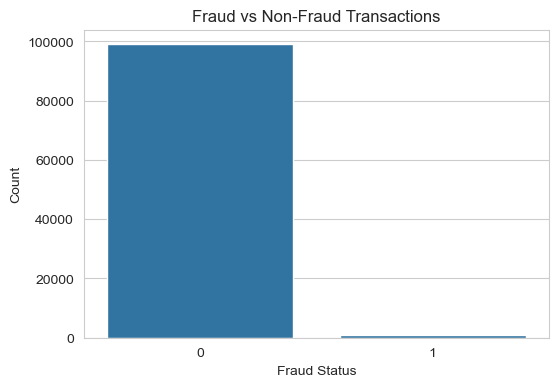

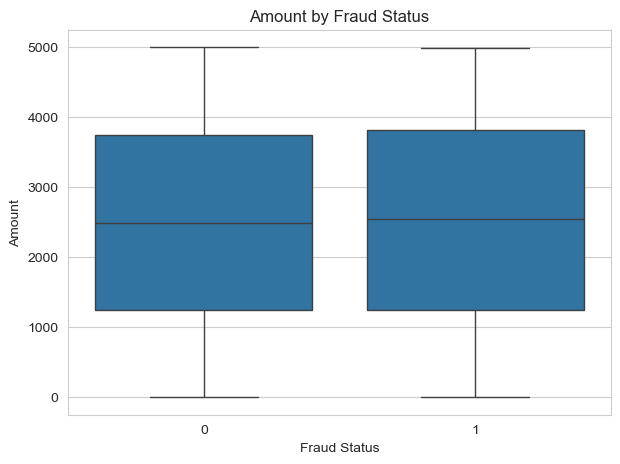

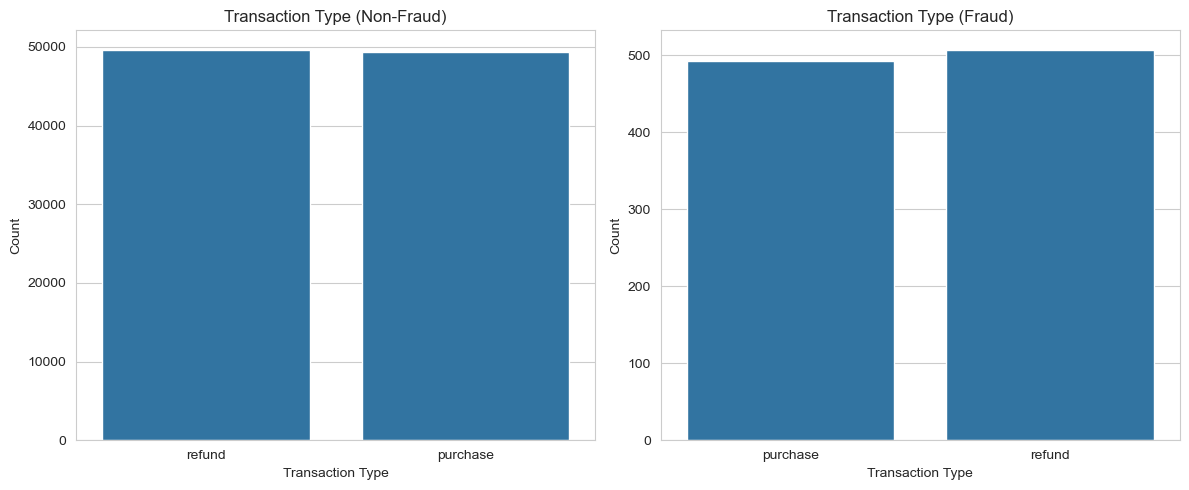

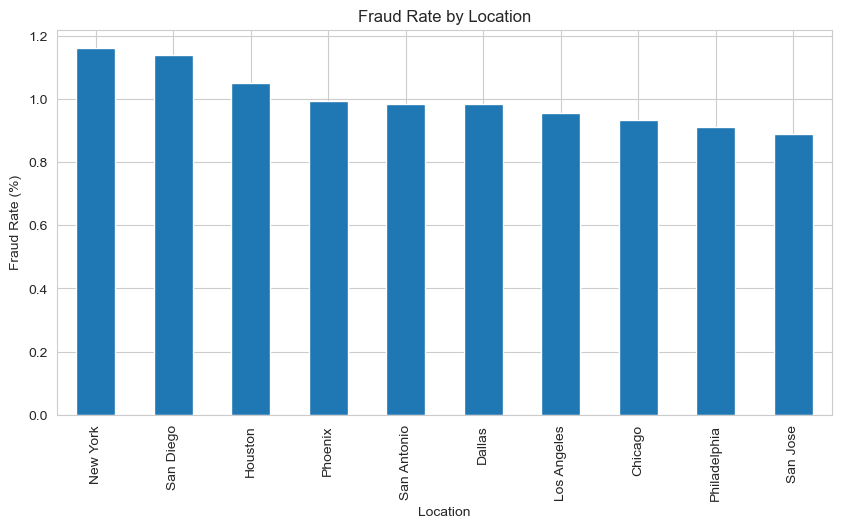


Fraud Rate by Transaction Type (%)
IsFraud                 0        1
TransactionType                   
purchase         99.01141  0.98859
refund           98.98865  1.01135

Fraud Rate by Location (%)
Location
New York        1.160813
San Diego       1.137375
Houston         1.050946
Phoenix         0.993976
San Antonio     0.983900
Dallas          0.982533
Los Angeles     0.956119
Chicago         0.932012
Philadelphia    0.911577
San Jose        0.887302
Name: IsFraud, dtype: float64

EDA completed.

Plots saved to:
C:\Users\ARNAB\OneDrive\Desktop\sumana_proj\EDA_Plots


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


file_path     = r"C:\Users\ARNAB\OneDrive\Desktop\sumana_proj\credit_card_fraud_dataset.csv"
output_folder = r"C:\Users\ARNAB\OneDrive\Desktop\sumana_proj\EDA_Plots"

os.makedirs(output_folder, exist_ok=True)

df = pd.read_csv(file_path)

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='%d-%m-%Y')

print("\nFraud Distribution:")
print(df['IsFraud'].value_counts())

print("\nFraud Percentage:")
print(df['IsFraud'].value_counts(normalize=True) * 100)

print("\nAverage Amount by Fraud Status")
amount_summary = df.groupby('IsFraud')['Amount'].agg(['count', 'mean', 'median', 'std'])
print(amount_summary)

sns.set_style("whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(x='IsFraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Count")
plt.savefig(os.path.join(output_folder, "fraud_vs_nonfraud.png"), dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(x='IsFraud', y='Amount', data=df)
plt.title("Amount by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Amount")
plt.savefig(os.path.join(output_folder, "amount_vs_fraud.png"), dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

nonfraud = df[df['IsFraud'] == 0]
sns.countplot(x='TransactionType', data=nonfraud, ax=axes[0])
axes[0].set_title("Transaction Type (Non-Fraud)")
axes[0].set_xlabel("Transaction Type")
axes[0].set_ylabel("Count")

fraud = df[df['IsFraud'] == 1]
sns.countplot(x='TransactionType', data=fraud, ax=axes[1])
axes[1].set_title("Transaction Type (Fraud)")
axes[1].set_xlabel("Transaction Type")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "transaction_type_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

fraud_rate_location = (
    df.groupby('Location')['IsFraud']
      .mean()
      .sort_values(ascending=False)
      * 100
)

plt.figure(figsize=(10, 5))
fraud_rate_location.plot(kind='bar')
plt.title("Fraud Rate by Location")
plt.xlabel("Location")
plt.ylabel("Fraud Rate (%)")
plt.savefig(os.path.join(output_folder, "fraud_rate_location.png"), dpi=300, bbox_inches='tight')
plt.show()

print("\nFraud Rate by Transaction Type (%)")
print(pd.crosstab(df['TransactionType'], df['IsFraud'], normalize='index') * 100)

print("\nFraud Rate by Location (%)")
print(fraud_rate_location)

print("\nEDA completed.")
print(f"\nPlots saved to:\n{output_folder}")


--- Feature Correlation with Fraud ---
  TransactionType  FraudRate
1          refund   0.010114
0        purchase   0.009886


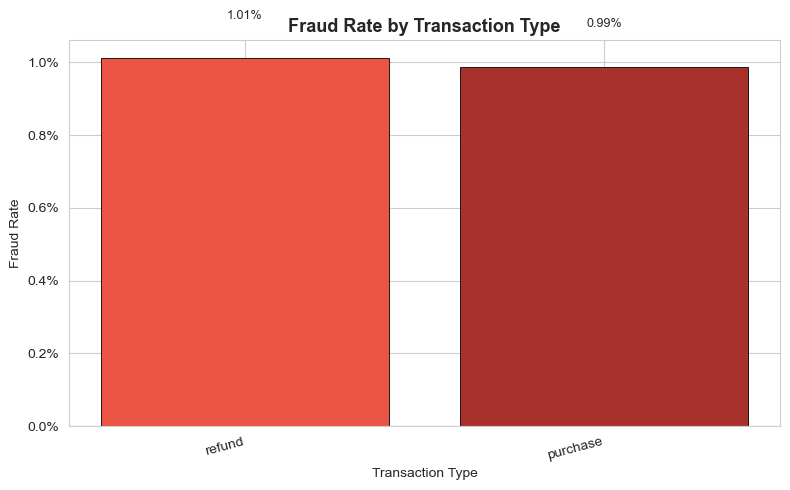


Correlation with IsFraud (numeric features):
Month       -0.004700
Amount       0.001399
DayOfWeek    0.000501
Weekend     -0.000290
Name: IsFraud, dtype: float64


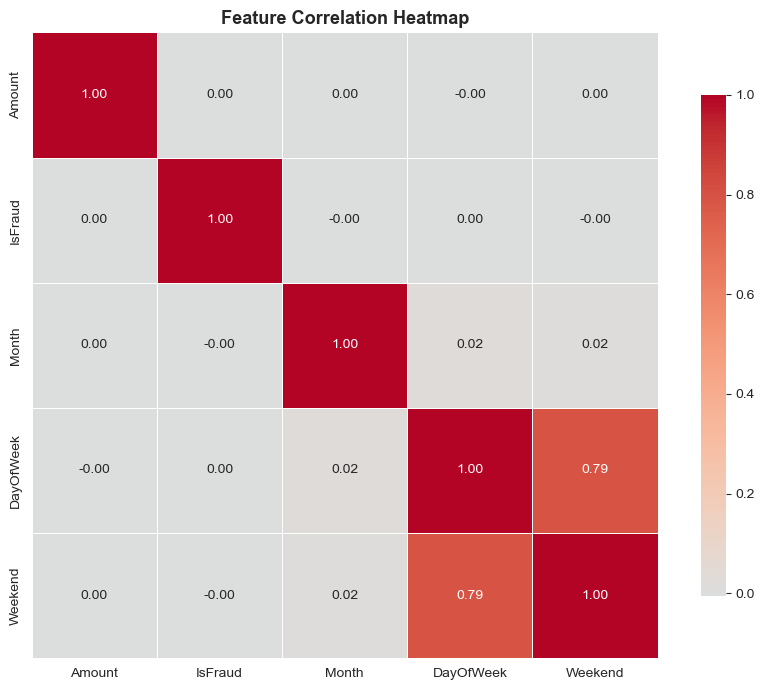

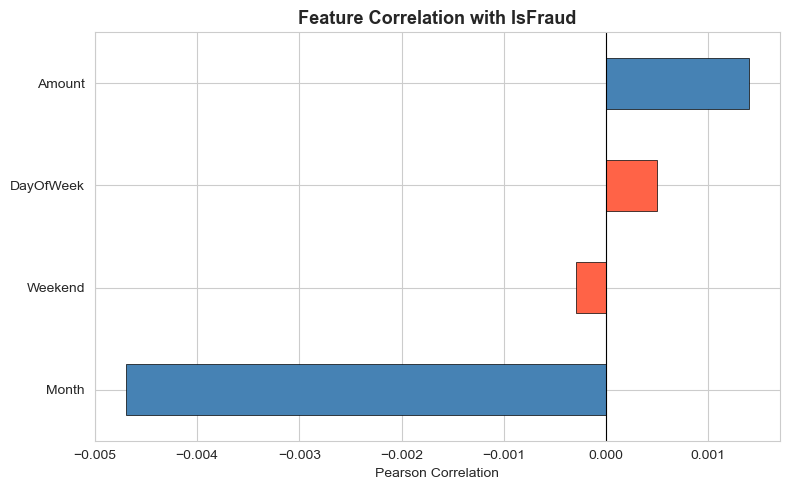


Training Logistic Regression


C:\Users\ARNAB\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Training Decision Tree

Training Random Forest

Training XGBoost
                 Model  Accuracy  Precision  Recall        F1   ROC_AUC
0  Logistic Regression   0.62095   0.010479   0.395  0.020416  0.527278
2        Random Forest   0.98845   0.000000   0.000  0.000000  0.514766
3              XGBoost   0.72070   0.010364   0.285  0.020000  0.484907
1        Decision Tree   0.67970   0.009640   0.305  0.018689  0.475461


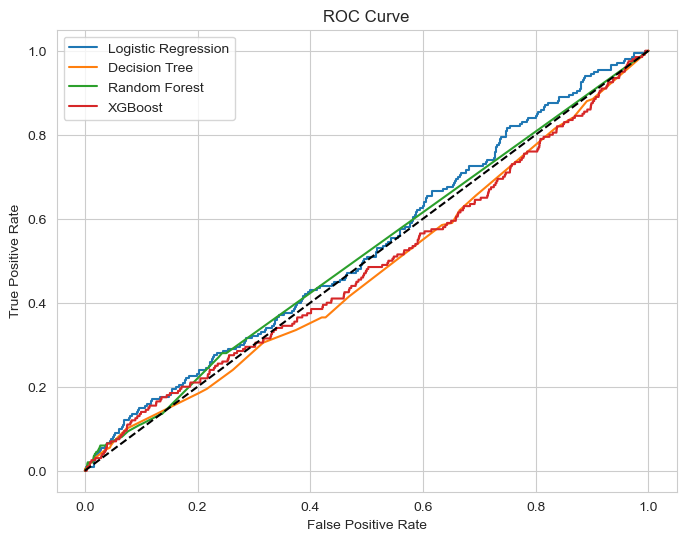

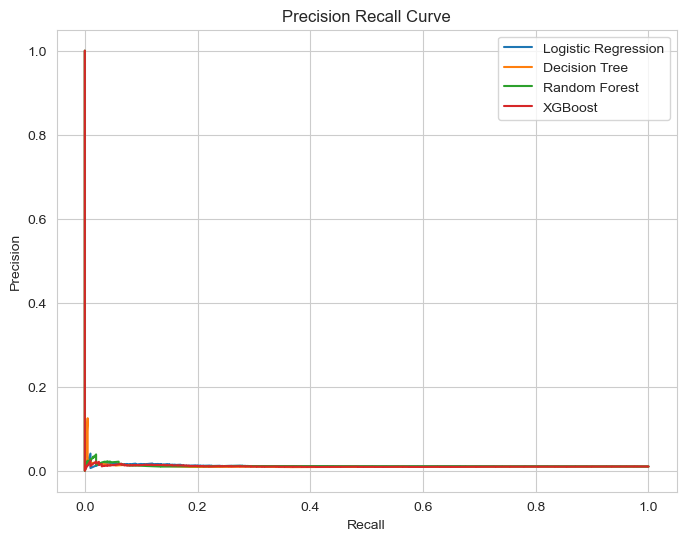

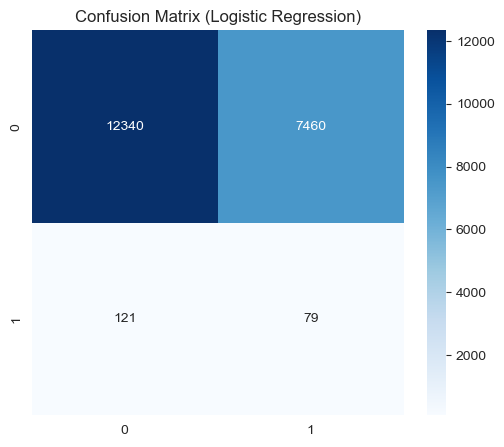

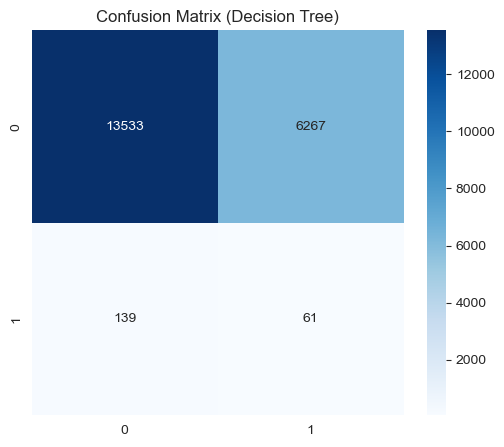

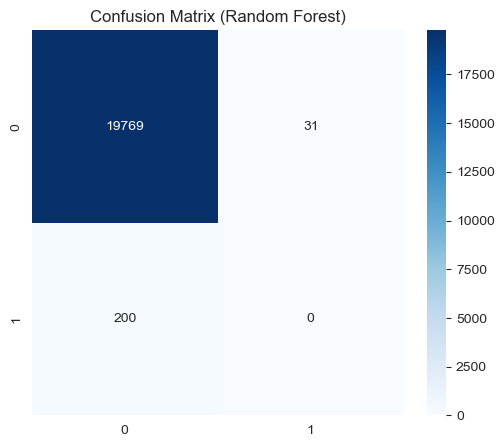

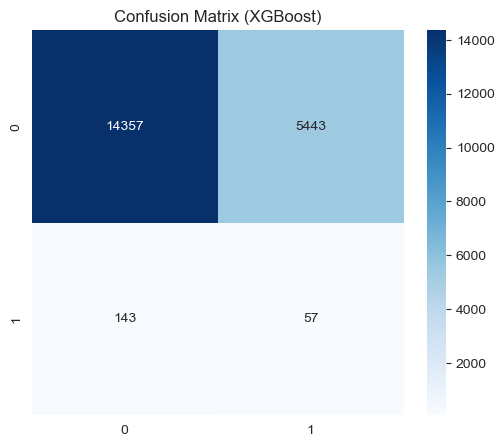

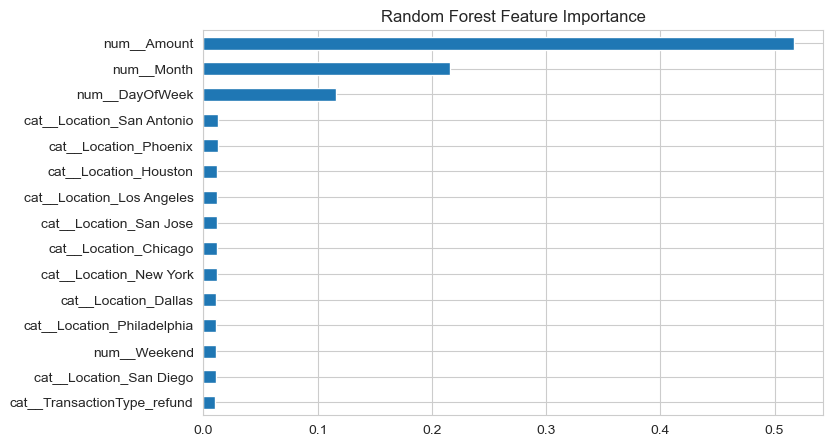


--- Threshold Tuning ---
Logistic Regression   best threshold=0.99  F1=0.0230  Prec=0.0122  Rec=0.1900


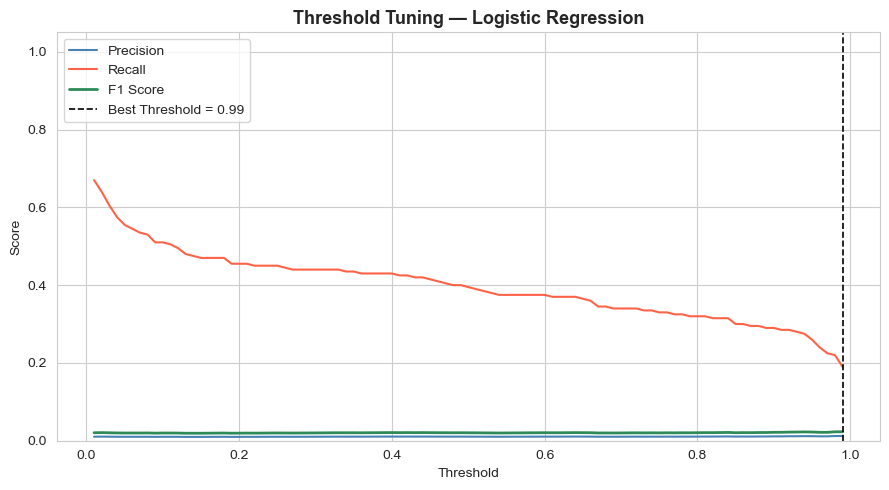

Decision Tree         best threshold=0.58  F1=0.0237  Prec=0.0135  Rec=0.1000


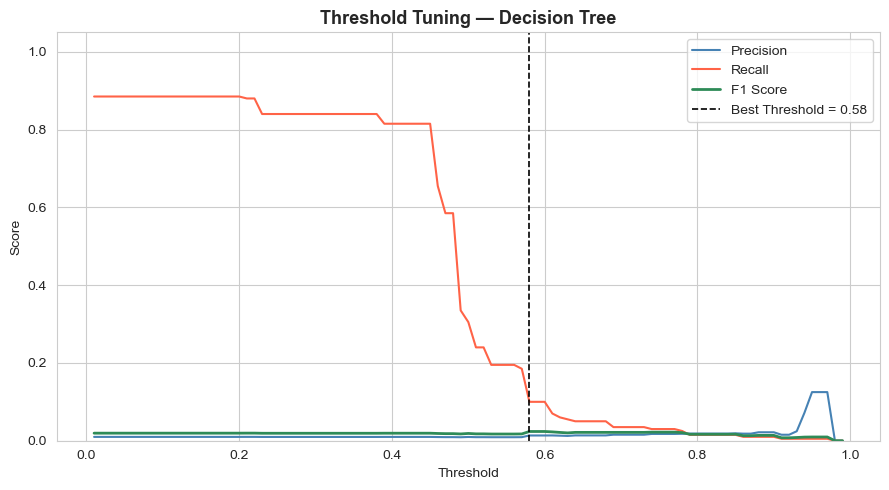

Random Forest         best threshold=0.06  F1=0.0317  Prec=0.0215  Rec=0.0600


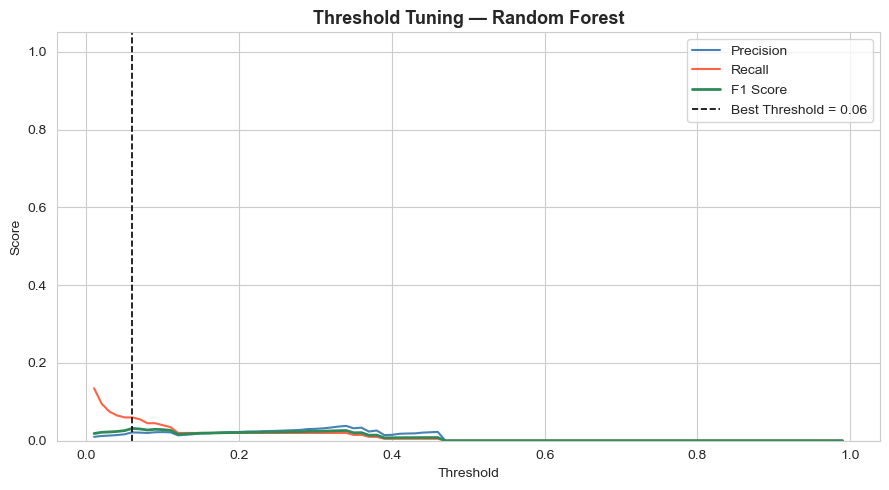

XGBoost               best threshold=0.62  F1=0.0258  Prec=0.0161  Rec=0.0650


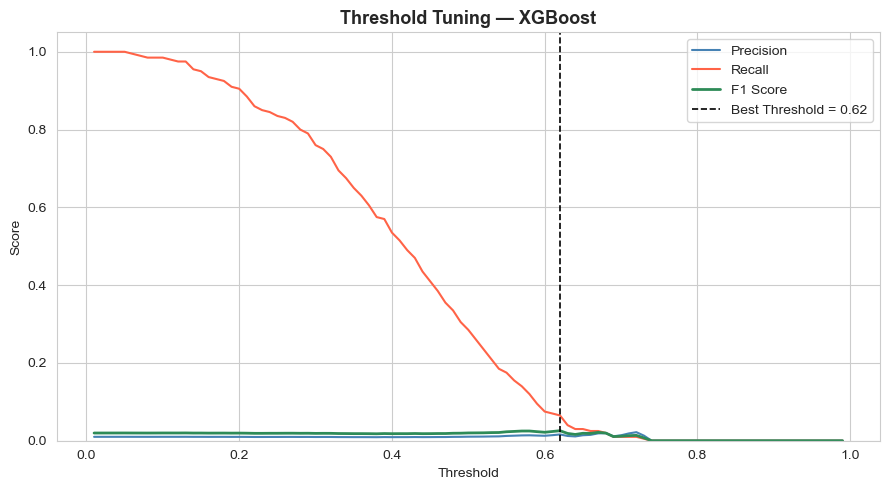


Threshold Tuning Summary:
              Model  Best_Threshold  Precision  Recall     F1
Logistic Regression            0.99     0.0122   0.190 0.0230
      Decision Tree            0.58     0.0135   0.100 0.0237
      Random Forest            0.06     0.0215   0.060 0.0317
            XGBoost            0.62     0.0161   0.065 0.0258

--- Calibration Curves ---


C:\Users\ARNAB\anaconda3\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\ARNAB\anaconda3\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\ARNAB\anaconda3\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\ARNAB\anaconda3\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


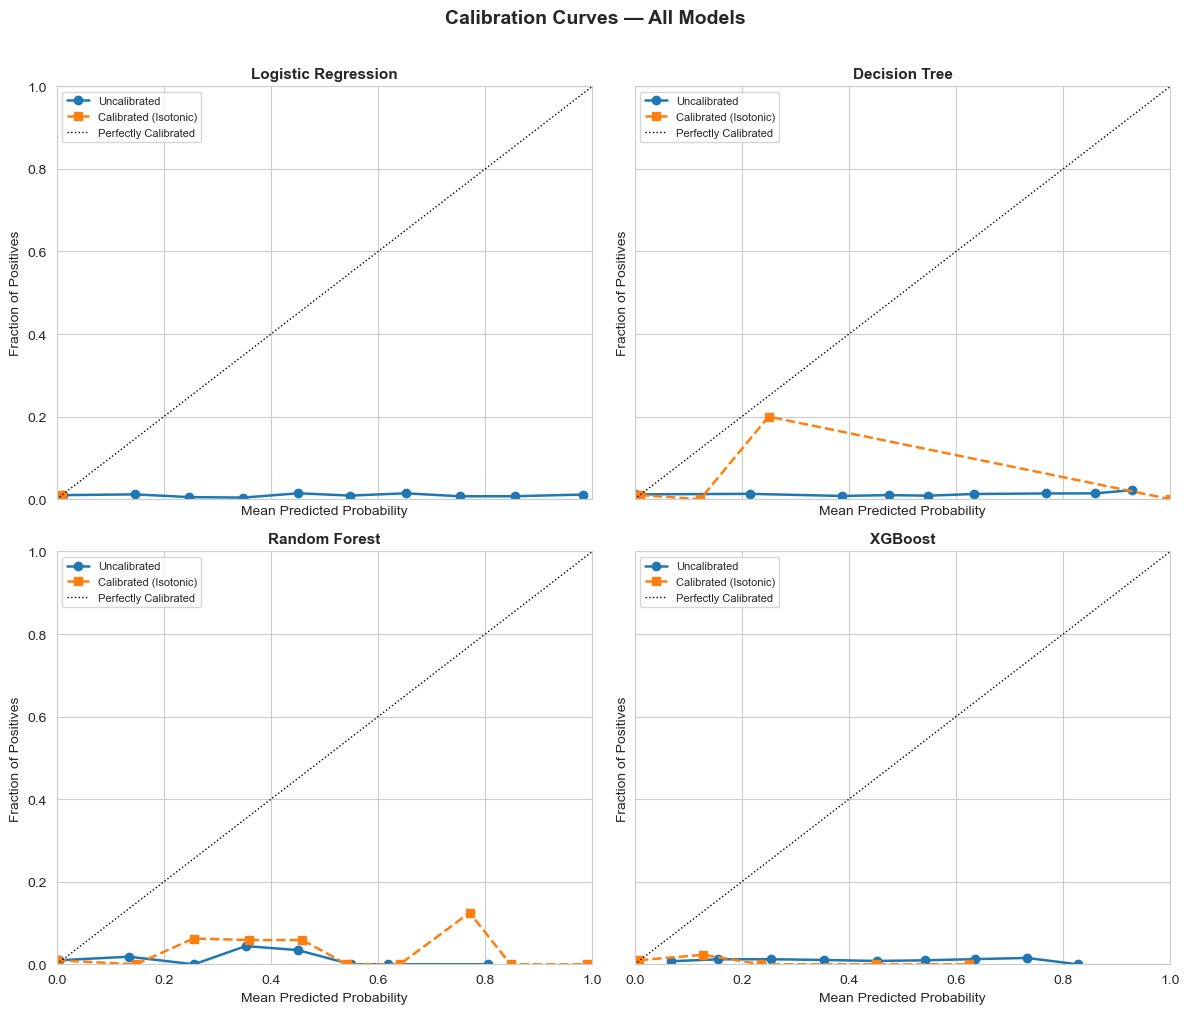


--- Cost Analysis ---
Logistic Regression   optimal threshold=0.99  min cost=£111,670
Decision Tree         optimal threshold=0.95  min cost=£99,570
Random Forest         optimal threshold=0.34  min cost=£99,010
XGBoost               optimal threshold=0.72  min cost=£99,890


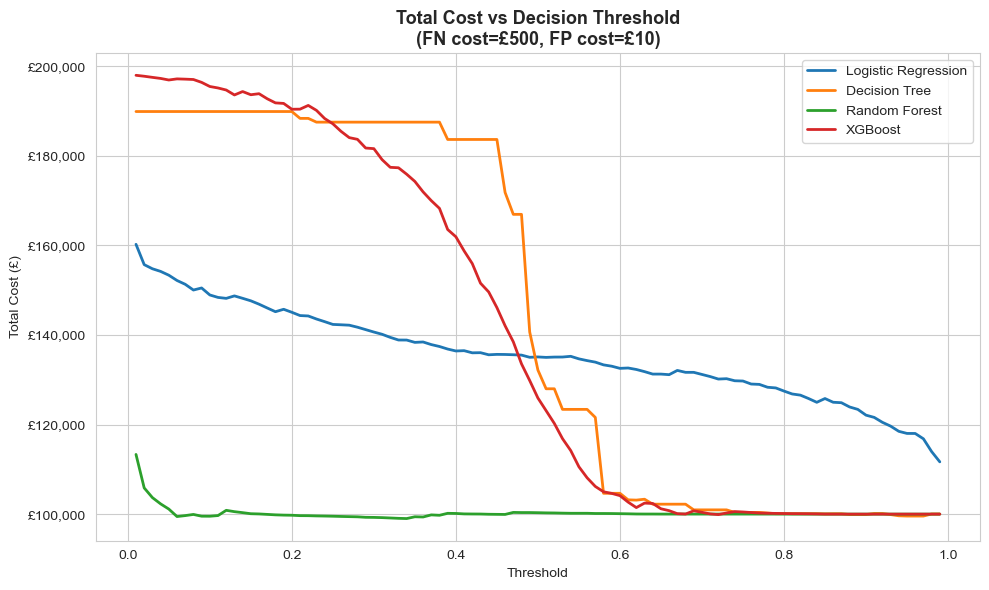

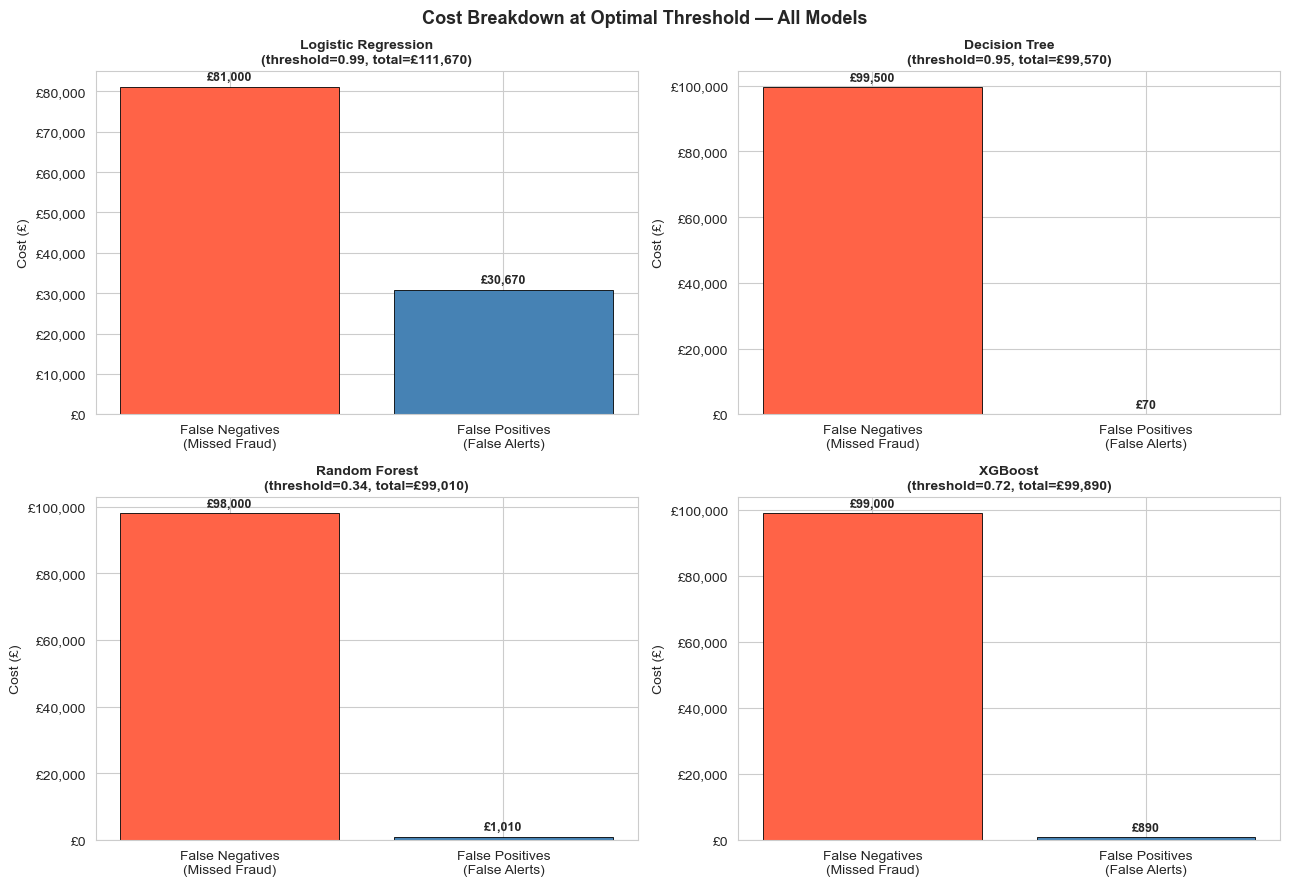


Cost Analysis Summary:
              Model  Optimal_Threshold  Min_Total_Cost_GBP
Logistic Regression               0.99              111670
      Decision Tree               0.95               99570
      Random Forest               0.34               99010
            XGBoost               0.72               99890

All outputs saved to:
C:\Users\ARNAB\OneDrive\Desktop\sumana_proj\Model_Results


In [31]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    label_binarize
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)


DATA_PATH = r"C:\Users\ARNAB\OneDrive\Desktop\sumana_proj\credit_card_fraud_dataset.csv"
RESULTS_FOLDER = r"C:\Users\ARNAB\OneDrive\Desktop\sumana_proj\Model_Results"

os.makedirs(RESULTS_FOLDER, exist_ok=True)

df = pd.read_csv(DATA_PATH)

df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='%d-%m-%Y')

df['Month']     = df['TransactionDate'].dt.month
df['DayOfWeek'] = df['TransactionDate'].dt.dayofweek
df['Weekend']   = (df['DayOfWeek'] >= 5).astype(int)

df.drop(columns=['TransactionID', 'MerchantID', 'TransactionDate'], inplace=True)

print("\n--- Feature Correlation with Fraud ---")

fraud_by_type = (
    df.groupby('TransactionType')['IsFraud']
      .mean()
      .reset_index()
      .rename(columns={'IsFraud': 'FraudRate'})
      .sort_values('FraudRate', ascending=False)
)

print(fraud_by_type)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    fraud_by_type['TransactionType'],
    fraud_by_type['FraudRate'],
    color=sns.color_palette("Reds_d", len(fraud_by_type)),
    edgecolor='black',
    linewidth=0.6
)

for bar, rate in zip(bars, fraud_by_type['FraudRate']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{rate:.2%}",
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Fraud Rate by Transaction Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Transaction Type')
ax.set_ylabel('Fraud Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FOLDER, 'fraud_rate_by_transaction_type.png'), dpi=300, bbox_inches='tight')
plt.show()

numeric_df  = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

fraud_corr = corr_matrix['IsFraud'].drop('IsFraud').sort_values(key=abs, ascending=False)

print("\nCorrelation with IsFraud (numeric features):")
print(fraud_corr)

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FOLDER, 'feature_correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
colors = ['tomato' if v > 0 else 'steelblue' for v in fraud_corr.values]
fraud_corr.sort_values().plot(kind='barh', color=colors, edgecolor='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with IsFraud', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FOLDER, 'feature_correlation_with_fraud.png'), dpi=300, bbox_inches='tight')
plt.show()

X = df.drop('IsFraud', axis=1)
y = df['IsFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

categorical_features = ['TransactionType', 'Location']
numeric_features     = ['Amount', 'Month', 'DayOfWeek', 'Weekend']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features)
])

models = {
    "Logistic Regression": LogisticRegression(
        solver='saga', max_iter=5000, class_weight='balanced', random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, class_weight='balanced', random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        scale_pos_weight=99, random_state=42, eval_metric='logloss'
    )
}

results        = []
roc_data       = {}
pr_data        = {}
trained_models = {}
prob_store     = {}

for name, model in models.items():

    print(f"\nTraining {name}")

    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)

    trained_models[name] = pipe

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    prob_store[name] = y_prob

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, f1, auc])

    fpr, tpr, _              = roc_curve(y_test, y_prob)
    roc_data[name]           = (fpr, tpr)

    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    pr_data[name]            = (recall_vals, precision_vals)

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC'])
results_df = results_df.sort_values(by='ROC_AUC', ascending=False)

print(results_df)
results_df.to_csv(os.path.join(RESULTS_FOLDER, 'model_comparison.csv'), index=False)

plt.figure(figsize=(8, 6))
for model_name, values in roc_data.items():
    plt.plot(values[0], values[1], label=model_name)
plt.plot([0, 1], [0, 1], '--', color='black')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.savefig(os.path.join(RESULTS_FOLDER, 'roc_curve.png'), dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
for model_name, values in pr_data.items():
    plt.plot(values[0], values[1], label=model_name)
plt.title('Precision Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.savefig(os.path.join(RESULTS_FOLDER, 'precision_recall_curve.png'), dpi=300, bbox_inches='tight')
plt.show()

for model_name, model in trained_models.items():
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix ({model_name})')

    filename = model_name.replace(" ", "_").lower() + "_confusion_matrix.png"
    plt.savefig(os.path.join(RESULTS_FOLDER, filename), dpi=300, bbox_inches='tight')
    plt.show()

rf           = trained_models['Random Forest']
feature_names = rf.named_steps['prep'].get_feature_names_out()

rf_imp = pd.Series(rf.named_steps['model'].feature_importances_, index=feature_names)
rf_imp = rf_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
rf_imp.sort_values().plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.savefig(os.path.join(RESULTS_FOLDER, 'rf_feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n--- Threshold Tuning ---")

threshold_results = []
thresholds_sweep  = np.arange(0.01, 1.00, 0.01)

for name, y_prob in prob_store.items():

    best_thresh = 0.5
    best_f1     = 0.0
    best_prec   = 0.0
    best_rec    = 0.0

    prec_list = []
    rec_list  = []
    f1_list   = []

    for thresh in thresholds_sweep:
        y_pred_t = (y_prob >= thresh).astype(int)

        p = precision_score(y_test, y_pred_t, zero_division=0)
        r = recall_score(y_test, y_pred_t, zero_division=0)
        f = f1_score(y_test, y_pred_t, zero_division=0)

        prec_list.append(p)
        rec_list.append(r)
        f1_list.append(f)

        if f > best_f1:
            best_f1     = f
            best_thresh = thresh
            best_prec   = p
            best_rec    = r

    threshold_results.append({
        'Model':          name,
        'Best_Threshold': round(best_thresh, 2),
        'Precision':      round(best_prec, 4),
        'Recall':         round(best_rec, 4),
        'F1':             round(best_f1, 4)
    })

    print(
        f"{name:20s}  best threshold={best_thresh:.2f}"
        f"  F1={best_f1:.4f}  Prec={best_prec:.4f}  Rec={best_rec:.4f}"
    )

    plt.figure(figsize=(9, 5))
    plt.plot(thresholds_sweep, prec_list, label='Precision', color='steelblue')
    plt.plot(thresholds_sweep, rec_list,  label='Recall',    color='tomato')
    plt.plot(thresholds_sweep, f1_list,   label='F1 Score',  color='seagreen', linewidth=2)
    plt.axvline(best_thresh, color='black', linestyle='--', linewidth=1.2, label=f'Best Threshold = {best_thresh:.2f}')
    plt.title(f'Threshold Tuning — {name}', fontsize=13, fontweight='bold')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()

    fname = name.replace(" ", "_").lower() + "_threshold_tuning.png"
    plt.savefig(os.path.join(RESULTS_FOLDER, fname), dpi=300, bbox_inches='tight')
    plt.show()

thresh_df = pd.DataFrame(threshold_results)
print("\nThreshold Tuning Summary:")
print(thresh_df.to_string(index=False))
thresh_df.to_csv(os.path.join(RESULTS_FOLDER, 'threshold_tuning_summary.csv'), index=False)

print("\n--- Calibration Curves ---")

n_bins = 10

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.ravel()

for idx, (name, y_prob) in enumerate(prob_store.items()):

    ax = axes[idx]

    frac_pos_raw, mean_pred_raw = calibration_curve(y_test, y_prob, n_bins=n_bins, strategy='uniform')
    ax.plot(mean_pred_raw, frac_pos_raw, marker='o', linewidth=1.8, label='Uncalibrated')

    base_pipe = trained_models[name]
    cal_model = CalibratedClassifierCV(base_pipe, method='isotonic', cv='prefit')
    cal_model.fit(X_train, y_train)

    y_prob_cal = cal_model.predict_proba(X_test)[:, 1]

    frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_prob_cal, n_bins=n_bins, strategy='uniform')
    ax.plot(mean_pred_cal, frac_pos_cal, marker='s', linewidth=1.8, linestyle='--', label='Calibrated (Isotonic)')

    ax.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Perfectly Calibrated')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

fig.suptitle('Calibration Curves — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FOLDER, 'calibration_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n--- Cost Analysis ---")

COST_FN = 500
COST_FP = 10

cost_results = []

plt.figure(figsize=(10, 6))

for name, y_prob in prob_store.items():

    costs     = []
    best_cost = np.inf
    best_t    = 0.5

    for thresh in thresholds_sweep:
        y_pred_t = (y_prob >= thresh).astype(int)

        cm_t = confusion_matrix(y_test, y_pred_t, labels=[0, 1])
        tn, fp, fn, tp = cm_t.ravel()

        total_cost = fn * COST_FN + fp * COST_FP
        costs.append(total_cost)

        if total_cost < best_cost:
            best_cost = total_cost
            best_t    = thresh

    cost_results.append({
        'Model':              name,
        'Optimal_Threshold':  round(best_t, 2),
        'Min_Total_Cost_GBP': int(best_cost)
    })

    print(f"{name:20s}  optimal threshold={best_t:.2f}  min cost=£{int(best_cost):,}")
    plt.plot(thresholds_sweep, costs, label=name, linewidth=2)

plt.title(
    f'Total Cost vs Decision Threshold\n(FN cost=£{COST_FN:,}, FP cost=£{COST_FP:,})',
    fontsize=13, fontweight='bold'
)
plt.xlabel('Threshold')
plt.ylabel('Total Cost (£)')
plt.legend()
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{int(x):,}'))
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FOLDER, 'cost_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for idx, (name, y_prob) in enumerate(prob_store.items()):

    opt_thresh = next(r['Optimal_Threshold'] for r in cost_results if r['Model'] == name)
    y_pred_opt = (y_prob >= opt_thresh).astype(int)

    cm_opt = confusion_matrix(y_test, y_pred_opt, labels=[0, 1])
    tn, fp, fn, tp = cm_opt.ravel()

    cost_fn_total = fn * COST_FN
    cost_fp_total = fp * COST_FP
    total         = cost_fn_total + cost_fp_total

    ax   = axes[idx]
    bars = ax.bar(
        ['False Negatives\n(Missed Fraud)', 'False Positives\n(False Alerts)'],
        [cost_fn_total, cost_fp_total],
        color=['tomato', 'steelblue'],
        edgecolor='black', linewidth=0.6
    )

    for bar, val in zip(bars, [cost_fn_total, cost_fp_total]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.01,
            f'£{val:,}',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

    ax.set_title(f'{name}\n(threshold={opt_thresh:.2f}, total=£{total:,})', fontsize=10, fontweight='bold')
    ax.set_ylabel('Cost (£)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{int(x):,}'))

fig.suptitle('Cost Breakdown at Optimal Threshold — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FOLDER, 'cost_breakdown_per_model.png'), dpi=300, bbox_inches='tight')
plt.show()

cost_df = pd.DataFrame(cost_results)
print("\nCost Analysis Summary:")
print(cost_df.to_string(index=False))
cost_df.to_csv(os.path.join(RESULTS_FOLDER, 'cost_analysis_summary.csv'), index=False)

print("\nAll outputs saved to:")
print(RESULTS_FOLDER)